In [1]:
import torch
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib


In [2]:
print(f"torch version : {torch.__version__}")
print(f"numpy version : {np.__version__}")
print(f"pandas version : {pd.__version__}")
print(f"matplotlib version : {matplotlib.__version__}")
print(f"seaborn version : {sns.__version__}")

print(f"gpu available : {torch.cuda.is_available()}")
print(f"Device : {torch.cuda.get_device_name(0)}")

torch version : 2.10.0+cu128
numpy version : 2.0.2
pandas version : 2.3.3
matplotlib version : 3.10.0
seaborn version : 0.13.2
gpu available : True
Device : Tesla T4


Problem 2

In [3]:
import random 

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)# ye all cpu operation ke liye seed hai
torch.cuda.manual_seed_all(seed)# ye all gpu operation ke liye seed hai

why gpu over cpu for deep learning??

In cpu there are less number of complex cores helpful for general works. but in deep learning we require several matrix multiplication in parallel and gpu have a throusands of smaller cores which helps in parallel computing .

In [4]:
import torchvision
import torchvision.transforms as transforms

mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True)
mnist_test = torchvision.datasets.MNIST(root='./data', train=False, download=True)

cifar_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
cifar_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.13MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.94MB/s]
100%|██████████| 170M/170M [00:02<00:00, 57.0MB/s]


In [5]:
print(f"MNIST Train Shape: {mnist_train.data.shape}")
print(f"MNIST Test Shape:  {mnist_test.data.shape}")

print(f"CIFAR Train Shape: {cifar_train.data.shape}")
print(f"CIFAR Test Shape:  {cifar_test.data.shape}")

MNIST Train Shape: torch.Size([60000, 28, 28])
MNIST Test Shape:  torch.Size([10000, 28, 28])
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape:  (10000, 32, 32, 3)


In [6]:
print(f"MNIST Dtype: {mnist_train.data.dtype}")
print(f"MNIST Range: {mnist_train.data.min()} to {mnist_train.data.max()}")

print(f"CIFAR Dtype: {cifar_train.data.dtype}")
print(f"CIFAR Range: {cifar_train.data.min()} to {cifar_train.data.max()}")

MNIST Dtype: torch.uint8
MNIST Range: 0 to 255
CIFAR Dtype: uint8
CIFAR Range: 0 to 255


In [7]:
targets = np.array(mnist_train.targets)
classes, counts = np.unique(targets, return_counts=True)
print("\nMNIST Samples per class:")
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count} samples")


MNIST Samples per class:
Class 0: 5923 samples
Class 1: 6742 samples
Class 2: 5958 samples
Class 3: 6131 samples
Class 4: 5842 samples
Class 5: 5421 samples
Class 6: 5918 samples
Class 7: 6265 samples
Class 8: 5851 samples
Class 9: 5949 samples



Figure saved as dataset_samples.png


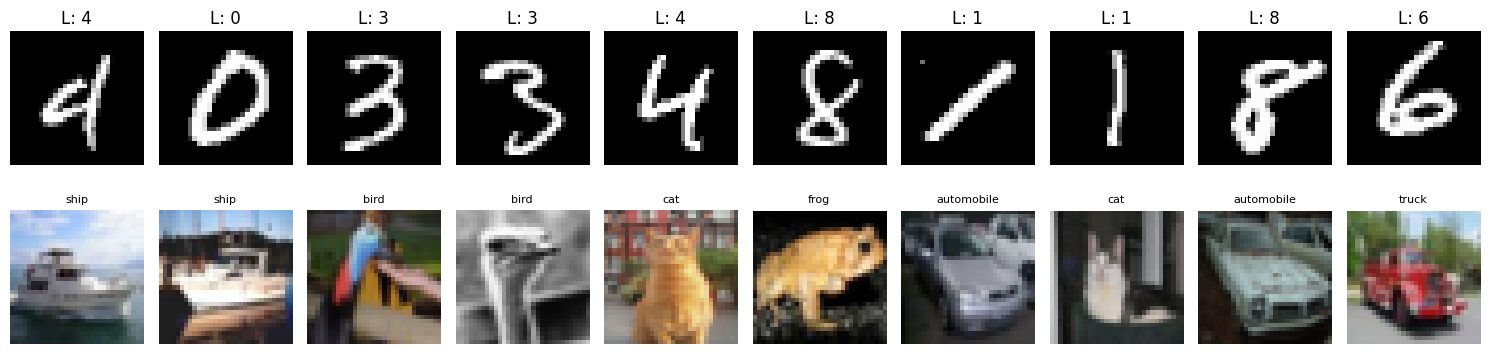

In [8]:
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                 'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i in range(10):
    idx_m = np.random.randint(0, len(mnist_train))
    axes[0, i].imshow(mnist_train.data[idx_m], cmap='gray')
    axes[0, i].set_title(f"L: {mnist_train.targets[idx_m]}")
    axes[0, i].axis('off')
    
    idx_c = np.random.randint(0, len(cifar_train))
    axes[1, i].imshow(cifar_train.data[idx_c])
    axes[1, i].set_title(cifar_classes[cifar_train.targets[idx_c]], fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples.png')
print("\nFigure saved as dataset_samples.png")
plt.show()

Problem 3

In [9]:
def preprocess(images, labels, is_mnist=True):
    print(f"Starting Preprocessing ({'MNIST' if is_mnist else 'CIFAR'})")
    
    print(f"Original Shape: {images.shape}, Dtype: {images.dtype}")
    print(f"Original Label Sample (first 5): {labels[:5]}")
    
    
    #normalize krenge 0 to 1 mein
    processed_images = images.astype('float32') / 255.0
    print(f"Normalized - Min: {processed_images.min()}, Max: {processed_images.max()}, Dtype: {processed_images.dtype}")
    
    #cifar mein channels aate hain but in mnsit we have to give 1 channel its not already there
    if is_mnist:
        processed_images = processed_images.reshape(-1, 28, 28, 1)
    else:
        processed_images = processed_images.reshape(-1, 32, 32, 3)
    print(f"Reshaped - New Shape: {processed_images.shape}")
    
    #yhan hmne one hot encoding ki hai jaise agr class 3 hai to uski jgh 0 0 1 0 0 0 0 0 0 0
    num_classes = 10
    one_hot_labels = np.eye(num_classes)[labels]
    print(f"One-Hot - First label vector:\n{one_hot_labels[0]}")
    
    return processed_images, one_hot_labels

In [10]:
mnist_images_raw = mnist_train.data.numpy()
mnist_labels_raw = mnist_train.targets.numpy()

X_train, y_train = preprocess(mnist_images_raw, mnist_labels_raw, is_mnist=True)

cifar_images_raw = np.array(cifar_train.data)
cifar_labels_raw = np.array(cifar_train.targets)
X_train_c, y_train_c = preprocess(cifar_images_raw, cifar_labels_raw, is_mnist=False)

Starting Preprocessing (MNIST)
Original Shape: (60000, 28, 28), Dtype: uint8
Original Label Sample (first 5): [5 0 4 1 9]
Normalized - Min: 0.0, Max: 1.0, Dtype: float32
Reshaped - New Shape: (60000, 28, 28, 1)
One-Hot - First label vector:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Starting Preprocessing (CIFAR)
Original Shape: (50000, 32, 32, 3), Dtype: uint8
Original Label Sample (first 5): [6 9 9 4 1]
Normalized - Min: 0.0, Max: 1.0, Dtype: float32
Reshaped - New Shape: (50000, 32, 32, 3)
One-Hot - First label vector:
[0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


Problem 4

In [11]:
from PIL import Image

In [12]:
augement_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees = 10),
    transforms.RandomResizedCrop(size=32,scale=(0.9,1.0)),
    transforms.ToTensor()
])

In [13]:
from torchvision import datasets
raw_cifar = datasets.CIFAR10(root='./data', train=True, download=True)

image saved.png


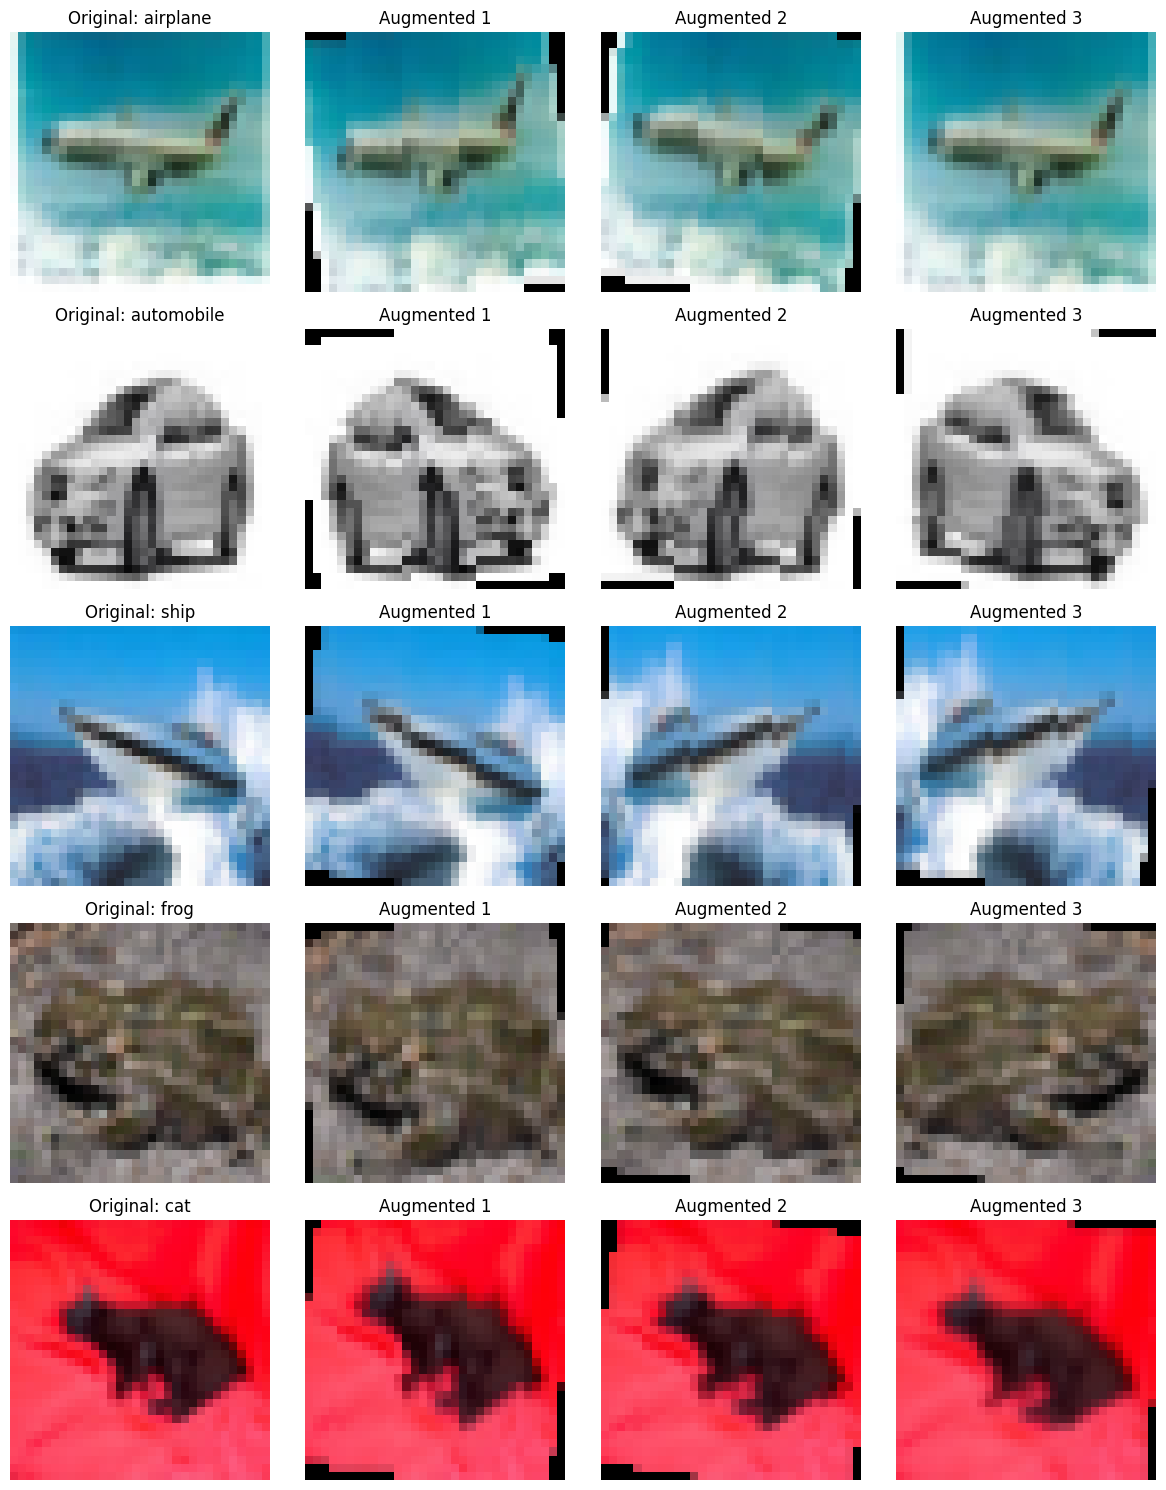

In [14]:
fig,axes = plt.subplots(5,4,figsize=(12,15))

for i in range(5):

    img_pil , label = raw_cifar[np.random.randint(0,1000)]
    class_name = raw_cifar.classes[label]

    #phele original dikhayenge
    axes[i,0].imshow(img_pil)
    axes[i,0].set_title(f"Original: {class_name}")
    axes[i,0].axis('off')

    for j in range(1,4):
        aug_tensor = augement_pipeline(img_pil)
        #ab vapis se tensor se numpy mein krenge to show the image
        # (C,H,W)(tensor) ->  (H,W,C)
        aug_img = aug_tensor.permute(1,2,0).numpy()

        axes[i,j].imshow(aug_img)
        axes[i,j].set_title(f"Augmented {j}")
        axes[i,j].axis('off')

plt.tight_layout()
plt.savefig('augementation_demo.png')
print("image saved.png")
plt.show()
        

Augumentation should only be applid to the trainig set only beacuse it increases the data set and also improves generalization . It should not be applied in the test sets because they must remain unchanged or untouched to provide a fair and unbiased evaluation to the models performance.

In a tensor of shape $(N, H, W, C)$, the channel dimension ($C$) represents the depth of the data, or the number of different types of information stored for every single pixel. In a grayscale image, the channel dimension is 1 because there is only one value needed to describe the intensity of light (from black to white). In an RGB image, the channel dimension is 3, as it stores three separate values representing the Red, Green, and Blue light intensities that combine to form the final color.

To train on large 1024×1024 satellite images without crashing your system, you should use Mini-batch Gradient Descent and Image Tiling. Mini-batching involves loading only a small subset of images (e.g., 4 or 8) into the GPU memory at a time rather than the entire dataset, which keeps memory usage constant regardless of dataset size. Image Tiling (or cropping) involves breaking each large 1024×1024 image into smaller, overlapping patches (like 256×256) and training the model on these patches; this significantly reduces the size of the activation maps stored in memory during the forward pass. Using these together ensures that even high-resolution data can be processed on standard hardware.

Applying normalization to the test set using its own mean and standard deviation is a mistake because it causes Data Leakage. In a real-world scenario, the model must treat the test set (or any new incoming data) as completely unseen, meaning it shouldn't know anything about the distribution of that data beforehand. By calculating the test set's own statistics, you are essentially "peeking" at the future. The correct approach is to use the mean and standard deviation from the training set to normalize the test set; this ensures the model is evaluated on how well it generalizes to new data based only on the information it learned during training.

**Task 2**

In [15]:
def conv2d(image , kernel,stride=1,padding=0):
    img_h , img_w = image.shape
    kern_h , kern_w = kernel.shape

    if padding > 0 :
        image = np.pad(image,pad_width=padding,mode='constant',constant_values=0)
        img_h,img_w = image.shape

    out_h = (img_h - kern_h)// stride + 1
    out_w = (img_w - kern_w)// stride + 1

    feature_map = np.zeros((out_h,out_w))

    for y in range(0,out_h):
        for x in range(0,out_w):
            y_start = y*stride
            y_end = y_start + kern_h
            x_start = x*stride
            x_end = x_start + kern_w

            patch = image[y_start:y_end , x_start:x_end]
            feature_map[y,x] = np.sum(patch*kernel)

    return feature_map

In [16]:
image_data = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
])

In [17]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

In [18]:
output = conv2d(image_data,sobel_x,stride=1,padding=0)

print("2D Convolution Output:")
print(output)
print(f"Output Shape : {output.shape}")
print(f"Verification: (5 - 3)/1 + 1 = {int(output.shape[0])}")

2D Convolution Output:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape : (3, 3)
Verification: (5 - 3)/1 + 1 = 3


Task 2 problem 2 numericla later

**Problem 3 (Task 2)**

In [19]:
import torch
import torch.nn as nn

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # C1: Conv2D(6 filters, 5x5, valid)
        # Input: (1, 28, 28) -> Output: (6, 24, 24)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1, padding=0)
        self.tanh1 = nn.Tanh()
        
        # S2: AvgPool(2x2, stride 2)
        # Output: (6, 12, 12)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # C3: Conv2D(16 filters, 5x5, valid)
        # Output: (16, 8, 8)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.tanh2 = nn.Tanh()
        
        # S4: AvgPool(2x2, stride 2)
        # Output: (16, 4, 4)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Flatten: 16 * 4 * 4 = 256
        self.flatten = nn.Flatten()
        
        # C5: Dense(120)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.tanh3 = nn.Tanh()
        
        # F6: Dense(84)
        self.fc2 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        
        # Output: Dense(10)
        self.fc3 = nn.Linear(84, 10)
        # Note: Softmax is usually applied in the Loss Function (CrossEntropyLoss) in PyTorch

    def forward(self, x):
        x = self.tanh1(self.conv1(x))
        x = self.pool1(x)
        x = self.tanh2(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.tanh3(self.fc1(x))
        x = self.tanh4(self.fc2(x))
        x = self.fc3(x)
        return x

# (a) Verify Model Summary
# Using torchsummary if available, otherwise manual print
model = LeNet5()
print(model)

# To check exact param count:
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Parameters: {total_params:,}")
# In PyTorch, this will be 44,426

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (tanh1): Tanh()
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (tanh2): Tanh()
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (tanh3): Tanh()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (tanh4): Tanh()
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Total Parameters: 44,426


In [20]:
import torch.nn as nn 

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5,self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1,out_channels=6,kernel_size=5,stride=1,padding=0)
        self.tanh1 = nn.Tanh()

        self.pool1 = nn.AvgPool2d(kernel_size=2,stride=2)

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.tanh2 = nn.Tanh()

        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(16*4*4,120)
        self.tanh3 = nn.Tanh()

        self.fc2 = nn.Linear(120,84)
        self.tanh4 = nn.Tanh()

        self.fc3  = nn.Linear(84,10)

    def forward(self,x):
        x= self.tanh1(self.conv1(x))
        x = self.pool1(x)
        x = self.tanh2(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.tanh3(self.fc1(x))
        x = self.tanh4(self.fc2(x))
        x = self.fc3(x)
        return x


In [21]:
model = LeNet5()
print(model)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (tanh1): Tanh()
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (tanh2): Tanh()
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=256, out_features=120, bias=True)
  (tanh3): Tanh()
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (tanh4): Tanh()
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [22]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parametes: {total_params:,}")

Total Parametes: 44,426


(b) numerical

Why here is Average Pooling?? when today max pooling is more common

LeNet-5 designed for simple images.
idea was dont keep the strongest feature just keep the overall average info.
at that time datasets were small ,images were simple and deep networks were not yet common and computing power was limited so they prefer stable + smooth feature reduction

but nowages complex scenes are used so max pooling is used which detects the strongest features and if the feature is slightly shifted max pooling will capture it 

Problem 4 (Task 2)

In [23]:
class CustomCIFAR10(nn.Module):
    def __init__(self):
        super(CustomCIFAR10,self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.relu_fc = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.relu_fc(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x     
        

In [24]:
model = CustomCIFAR10()
total_params = sum(p.numel() for p in model.parameters())

In [25]:
print(f"Custom CNN Summary")
print(model)
print(f"\nTotal Parameters: {total_params:,}")

if 200_000 <= total_params <= 2_000_000:
    print("Parameter count check: PASSED")
else:
    print("Parameter count check: FAILED")

Custom CNN Summary
CustomCIFAR10(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=2048, out_featu

Role Of Batch Normalization 

during training, the distribution of inputs to internal layers changes constantly. batchNorm forces the activations throuhout the netrwerok to take on a unit standard vebiation and zero mean.

it should be placed before the activation function because for activations like tanh or sigmoid batchnorm enures values dont get pushed into the flat regions where gradients disappear(vanishing gradient problem).


2 emprical benefits

without the btchnorm , you have to use small learning rates to prevent the gradients from exploding or vanising

BatchNorm adds a small amount of "noise" to the training process because the mean and variance are calculated over mini-batches rather than the whole dataset. This acts as a form of regularization

Task 3

Problem 1 (task 3)

In [26]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split


X_tensor = torch.tensor(X_train).permute(0, 3, 1, 2)
y_tensor = torch.tensor(np.argmax(y_train, axis=1)).long()

dataset = TensorDataset(X_tensor, y_tensor)
val_size = int(0.1 * len(dataset))
train_size = len(dataset) - val_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [28]:
epochs = 15
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    model.train()
    t_loss, t_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        t_loss += loss.item()
        t_correct += (outputs.argmax(1) == labels).sum().item()
    
   
    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            v_loss += criterion(outputs, labels).item()
            v_correct += (outputs.argmax(1) == labels).sum().item()
            
    history['train_loss'].append(t_loss / len(train_loader))
    history['val_loss'].append(v_loss / len(val_loader))
    history['train_acc'].append(t_correct / train_size)
    history['val_acc'].append(v_correct / val_size)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {history['train_loss'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

Epoch 1/15 - Loss: 1.9854 - Val Acc: 0.7318
Epoch 2/15 - Loss: 0.6857 - Val Acc: 0.8657
Epoch 3/15 - Loss: 0.4349 - Val Acc: 0.8922
Epoch 4/15 - Loss: 0.3599 - Val Acc: 0.9017
Epoch 5/15 - Loss: 0.3152 - Val Acc: 0.9103
Epoch 6/15 - Loss: 0.2807 - Val Acc: 0.9180
Epoch 7/15 - Loss: 0.2511 - Val Acc: 0.9285
Epoch 8/15 - Loss: 0.2254 - Val Acc: 0.9335
Epoch 9/15 - Loss: 0.2033 - Val Acc: 0.9412
Epoch 10/15 - Loss: 0.1840 - Val Acc: 0.9460
Epoch 11/15 - Loss: 0.1678 - Val Acc: 0.9503
Epoch 12/15 - Loss: 0.1539 - Val Acc: 0.9545
Epoch 13/15 - Loss: 0.1421 - Val Acc: 0.9575
Epoch 14/15 - Loss: 0.1321 - Val Acc: 0.9610
Epoch 15/15 - Loss: 0.1233 - Val Acc: 0.9643


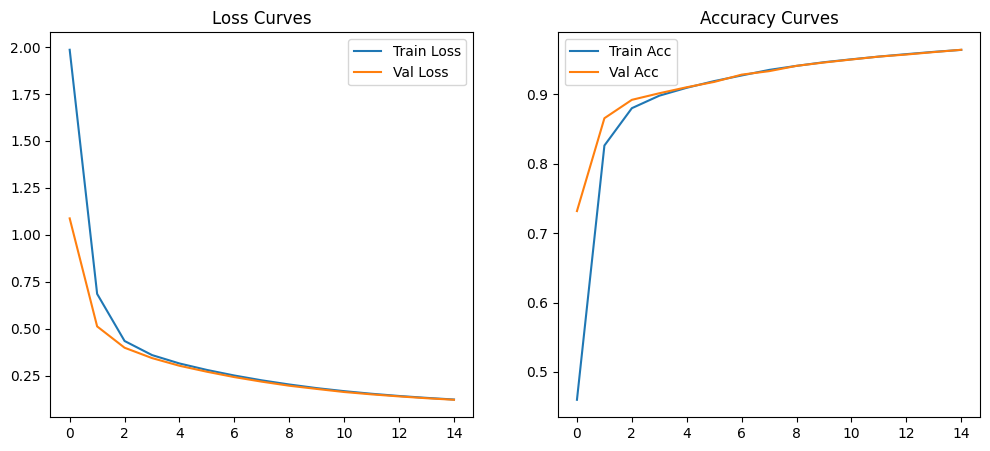

In [29]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_title('Loss Curves')
ax1.legend()

ax2.plot(history['train_acc'], label='Train Acc')
ax2.plot(history['val_acc'], label='Val Acc')
ax2.set_title('Accuracy Curves')
ax2.legend()

plt.savefig('lenet_sgd_curves.png')
plt.show()

In [30]:
dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

In [31]:
def train_model(optimizer_type, epochs=15):
    model = LeNet5().to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_type == 'momentum':
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    val_acc_history = []
    
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        
        acc = correct / total
        val_acc_history.append(acc)
        print(f"{optimizer_type} - Epoch {epoch+1}: Val Acc {acc:.4f}")
        
    return val_acc_history

In [32]:
history_sgd = train_model('sgd')
history_momentum = train_model('momentum')
history_adam = train_model('adam')

sgd - Epoch 1: Val Acc 0.6602
sgd - Epoch 2: Val Acc 0.8645
sgd - Epoch 3: Val Acc 0.8950
sgd - Epoch 4: Val Acc 0.9097
sgd - Epoch 5: Val Acc 0.9168
sgd - Epoch 6: Val Acc 0.9305
sgd - Epoch 7: Val Acc 0.9377
sgd - Epoch 8: Val Acc 0.9432
sgd - Epoch 9: Val Acc 0.9488
sgd - Epoch 10: Val Acc 0.9537
sgd - Epoch 11: Val Acc 0.9563
sgd - Epoch 12: Val Acc 0.9605
sgd - Epoch 13: Val Acc 0.9640
sgd - Epoch 14: Val Acc 0.9665
sgd - Epoch 15: Val Acc 0.9678
momentum - Epoch 1: Val Acc 0.9455
momentum - Epoch 2: Val Acc 0.9677
momentum - Epoch 3: Val Acc 0.9750
momentum - Epoch 4: Val Acc 0.9785
momentum - Epoch 5: Val Acc 0.9783
momentum - Epoch 6: Val Acc 0.9825
momentum - Epoch 7: Val Acc 0.9825
momentum - Epoch 8: Val Acc 0.9820
momentum - Epoch 9: Val Acc 0.9873
momentum - Epoch 10: Val Acc 0.9833
momentum - Epoch 11: Val Acc 0.9853
momentum - Epoch 12: Val Acc 0.9855
momentum - Epoch 13: Val Acc 0.9858
momentum - Epoch 14: Val Acc 0.9855
momentum - Epoch 15: Val Acc 0.9853
adam - Epoch 

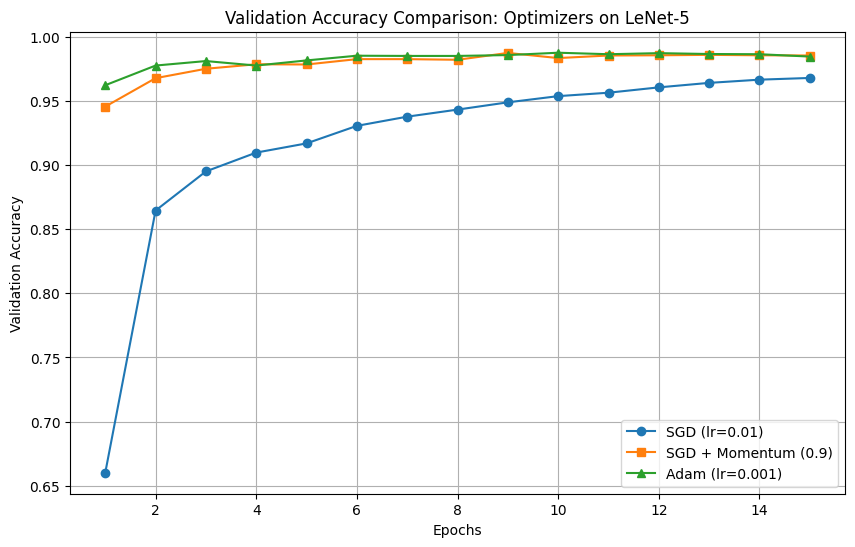

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), history_sgd, label='SGD (lr=0.01)', marker='o')
plt.plot(range(1, 16), history_momentum, label='SGD + Momentum (0.9)', marker='s')
plt.plot(range(1, 16), history_adam, label='Adam (lr=0.001)', marker='^')

plt.title('Validation Accuracy Comparison: Optimizers on LeNet-5')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('optimiser_comparison.png')
plt.show()

we can say fastest convergence as adam but there is like a drawish between adam and sgd + momentum

problem 3 ( task 3)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_cifar = torch.tensor(X_train_c).permute(0, 3, 1, 2).float()
y_cifar = torch.tensor(np.argmax(y_train_c, axis=1)).long()

dataset = TensorDataset(X_cifar, y_cifar)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size], 
                                generator=torch.Generator().manual_seed(42))

In [35]:
lrs = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]
epochs = 10
grid_results = {}

In [36]:
for lr in lrs:
    for bs in batch_sizes:
        print(f"\n>>> TESTING: LR={lr}, Batch Size={bs}")
        
        train_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=bs, shuffle=False)
        
        model = CustomCIFAR10().to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()
        
        for epoch in range(epochs):
            model.train()
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
        
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        grid_results[(lr, bs)] = val_acc
        print(f"Final Validation Accuracy: {val_acc:.2f}%")


>>> TESTING: LR=0.1, Batch Size=32
Final Validation Accuracy: 9.42%

>>> TESTING: LR=0.1, Batch Size=128
Final Validation Accuracy: 10.14%

>>> TESTING: LR=0.01, Batch Size=32
Final Validation Accuracy: 64.74%

>>> TESTING: LR=0.01, Batch Size=128
Final Validation Accuracy: 67.56%

>>> TESTING: LR=0.001, Batch Size=32
Final Validation Accuracy: 78.24%

>>> TESTING: LR=0.001, Batch Size=128
Final Validation Accuracy: 76.32%


In [37]:
print("\n" + "="*30)
print("GRID SEARCH RESULTS (3x2 Table)")
print("="*30)
print(f"{'LR / BS':<12} | {'32':<10} | {'128':<10}")
print("-" * 35)
for lr in lrs:
    acc_32 = f"{grid_results[(lr, 32)]:.2f}%"
    acc_128 = f"{grid_results[(lr, 128)]:.2f}%"
    print(f"{lr:<12} | {acc_32:<10} | {acc_128:<10}")


GRID SEARCH RESULTS (3x2 Table)
LR / BS      | 32         | 128       
-----------------------------------
0.1          | 9.42%      | 10.14%    
0.01         | 64.74%     | 67.56%    
0.001        | 78.24%     | 76.32%    


In [38]:
def train_variant(variant_name, train_loader, val_loader, device, epochs=20):
    class VarCNN(nn.Module):
        def __init__(self, name):
            super().__init__()
            self.name = name
            
            self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
            self.bn1 = nn.BatchNorm2d(32) if 'BN' in name else nn.Identity()
            self.pool1 = nn.MaxPool2d(2, 2)
            self.do1 = nn.Dropout(0.3) if 'DO' in name else nn.Identity()
            
            self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
            self.bn2 = nn.BatchNorm2d(64) if 'BN' in name else nn.Identity()
            self.pool2 = nn.MaxPool2d(2, 2)
            self.do2 = nn.Dropout(0.3) if 'DO' in name else nn.Identity()
            
            self.flatten = nn.Flatten()
            self.fc1 = nn.Linear(64 * 8 * 8, 256)
            self.do3 = nn.Dropout(0.5) if 'DO' in name else nn.Identity()
            self.fc2 = nn.Linear(256, 10)

        def forward(self, x):
            x = torch.relu(self.bn1(self.conv1(x)))
            x = self.do1(self.pool1(x))
            x = torch.relu(self.bn2(self.conv2(x)))
            x = self.do2(self.pool2(x))
            x = self.flatten(x)
            x = self.do3(torch.relu(self.fc1(x)))
            return self.fc2(x)

    model = VarCNN(variant_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    history = {'t_acc': [], 'v_acc': []}
    
    for epoch in range(epochs):
        model.train()
        t_correct, t_total = 0, 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            t_correct += (out.argmax(1) == lbls).sum().item()
            t_total += lbls.size(0)
            
        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                v_correct += (out.argmax(1) == lbls).sum().item()
                v_total += lbls.size(0)
        
        history['t_acc'].append(t_correct / t_total)
        history['v_acc'].append(v_correct / v_total)
        
    return history

In [39]:
results = {
    "None": train_variant("None", train_loader, val_loader, device),
    "Dropout": train_variant("DO", train_loader, val_loader, device),
    "Batch Norm": train_variant("BN", train_loader, val_loader, device),
    "Both": train_variant("BN_DO", train_loader, val_loader, device)
}

In [40]:
print("\n" + "="*50)
print(f"{'Variant':<20} | {'Train Acc':<10} | {'Val Acc':<10} | {'Gap':<10}")
print("-" * 50)

for name, hist in results.items():
    t_final = hist['t_acc'][-1]
    v_final = hist['v_acc'][-1]
    gap = t_final - v_final
    print(f"{name:<20} | {t_final:>9.2%} | {v_final:>8.2%} | {gap:>8.2%}")
print("="*50)


Variant              | Train Acc  | Val Acc    | Gap       
--------------------------------------------------
None                 |    97.38% |   69.06% |   28.32%
Dropout              |    69.92% |   71.00% |   -1.08%
Batch Norm           |    96.69% |   73.56% |   23.13%
Both                 |    56.28% |   68.80% |  -12.52%


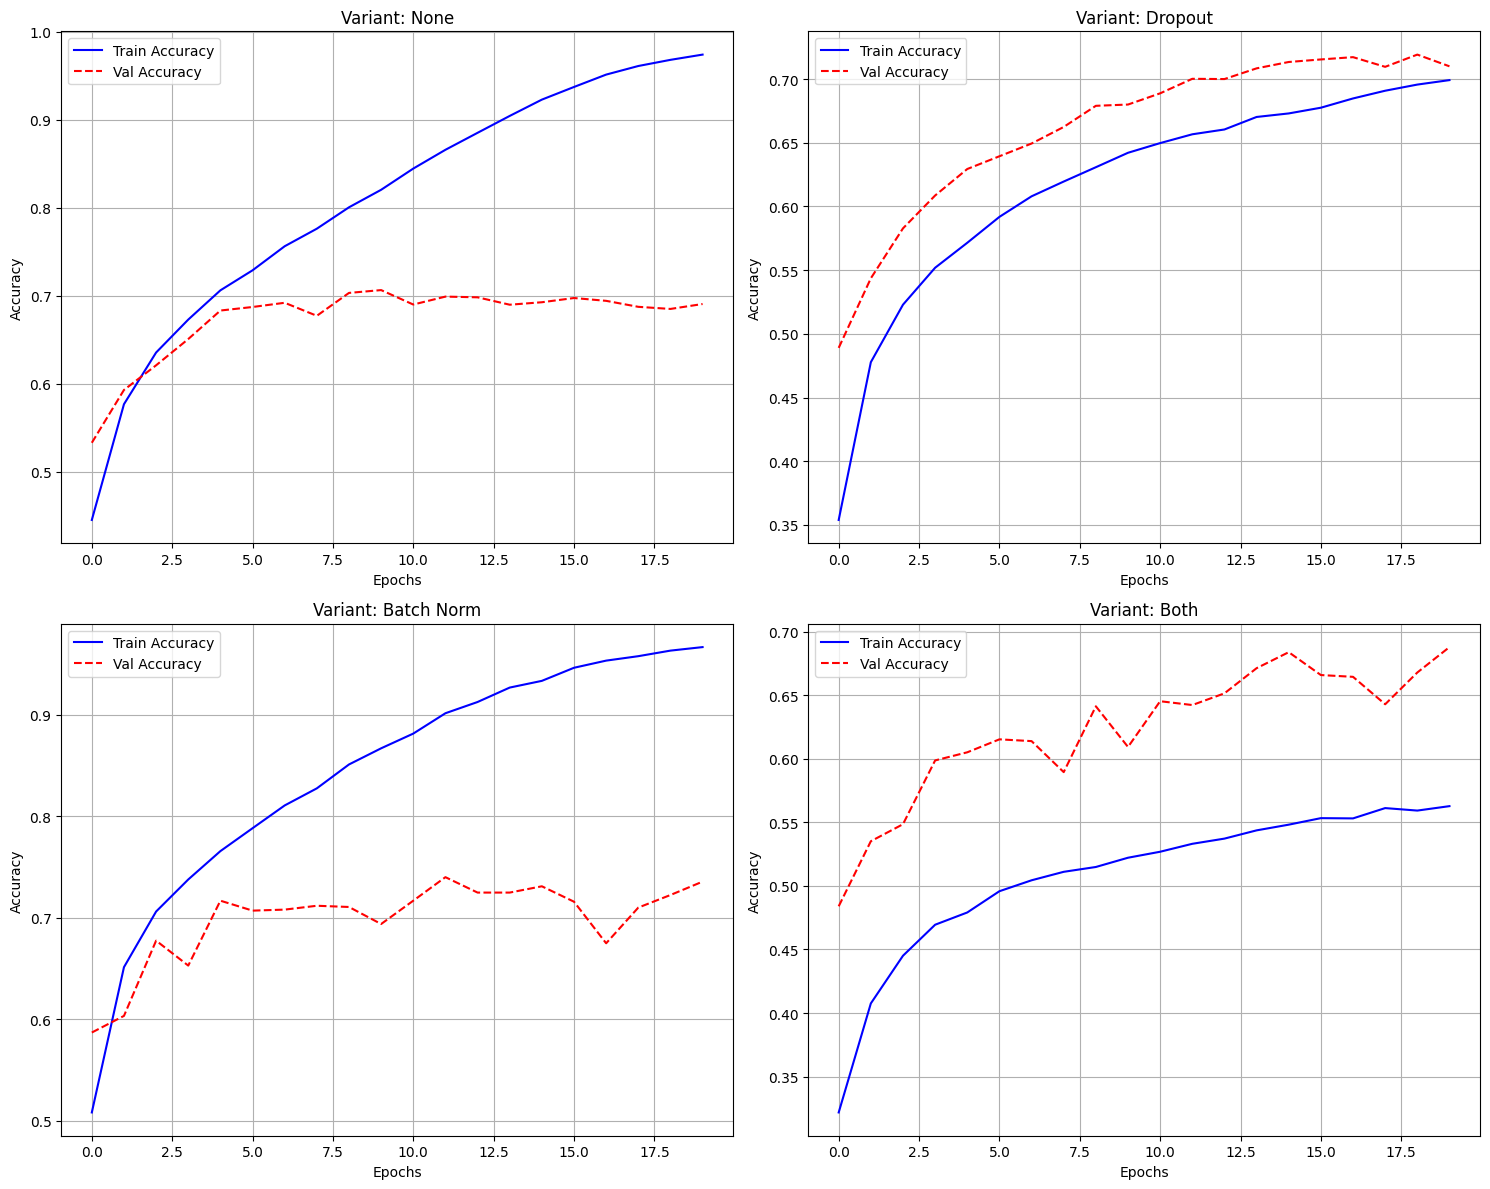

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, (name, hist) in enumerate(results.items()):
    axes[i].plot(hist['t_acc'], label='Train Accuracy', color='blue')
    axes[i].plot(hist['v_acc'], label='Val Accuracy', color='red', linestyle='--')
    axes[i].set_title(f"Variant: {name}")
    axes[i].set_xlabel("Epochs")
    axes[i].set_ylabel("Accuracy")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.savefig('regularization_experiment.png') 
plt.show()

In [42]:
class VarCNN(nn.Module):
    def __init__(self, name="BN_DO"):
        super().__init__()
        self.name = name
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if 'BN' in name else nn.Identity()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.do1 = nn.Dropout(0.3) if 'DO' in name else nn.Identity()
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if 'BN' in name else nn.Identity()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.do2 = nn.Dropout(0.3) if 'DO' in name else nn.Identity()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.do3 = nn.Dropout(0.5) if 'DO' in name else nn.Identity()
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.do1(self.pool1(x))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.do2(self.pool2(x))
        x = self.flatten(x)
        x = self.do3(torch.relu(self.fc1(x)))
        return self.fc2(x)

In [43]:
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR


def train_with_scheduler(scheduler_type, train_loader, val_loader, device, epochs=30):
    model = VarCNN("BN_DO").to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    if scheduler_type == "plateau":
        scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    else:
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
        
    lr_history = []
    val_acc_history = []
    
    for epoch in range(epochs):
        model.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
        
        model.eval()
        v_correct, v_total, v_loss = 0, 0, 0.0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                v_loss += criterion(out, lbls).item()
                v_correct += (out.argmax(1) == lbls).sum().item()
                v_total += lbls.size(0)
        
        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)
        val_acc_history.append(v_correct / v_total)
        
        if scheduler_type == "plateau":
            scheduler.step(v_loss / len(val_loader))
        else:
            scheduler.step()
            
        print(f"{scheduler_type} | Epoch {epoch+1} | LR: {current_lr:.6f} | Val Acc: {val_acc_history[-1]:.4f}")
            
    return lr_history, val_acc_history

In [44]:
lr_plat, acc_plat = train_with_scheduler("plateau", train_loader, val_loader, device)
lr_cos, acc_cos = train_with_scheduler("cosine", train_loader, val_loader, device)

plateau | Epoch 1 | LR: 0.001000 | Val Acc: 0.5110
plateau | Epoch 2 | LR: 0.001000 | Val Acc: 0.5486
plateau | Epoch 3 | LR: 0.001000 | Val Acc: 0.5980
plateau | Epoch 4 | LR: 0.001000 | Val Acc: 0.6038
plateau | Epoch 5 | LR: 0.001000 | Val Acc: 0.6474
plateau | Epoch 6 | LR: 0.001000 | Val Acc: 0.6576
plateau | Epoch 7 | LR: 0.001000 | Val Acc: 0.6638
plateau | Epoch 8 | LR: 0.001000 | Val Acc: 0.6166
plateau | Epoch 9 | LR: 0.001000 | Val Acc: 0.6728
plateau | Epoch 10 | LR: 0.001000 | Val Acc: 0.6098
plateau | Epoch 11 | LR: 0.001000 | Val Acc: 0.6076
plateau | Epoch 12 | LR: 0.000500 | Val Acc: 0.7028
plateau | Epoch 13 | LR: 0.000500 | Val Acc: 0.7132
plateau | Epoch 14 | LR: 0.000500 | Val Acc: 0.7144
plateau | Epoch 15 | LR: 0.000500 | Val Acc: 0.7186
plateau | Epoch 16 | LR: 0.000500 | Val Acc: 0.7256
plateau | Epoch 17 | LR: 0.000500 | Val Acc: 0.7254
plateau | Epoch 18 | LR: 0.000500 | Val Acc: 0.7328
plateau | Epoch 19 | LR: 0.000500 | Val Acc: 0.7284
plateau | Epoch 20 | 

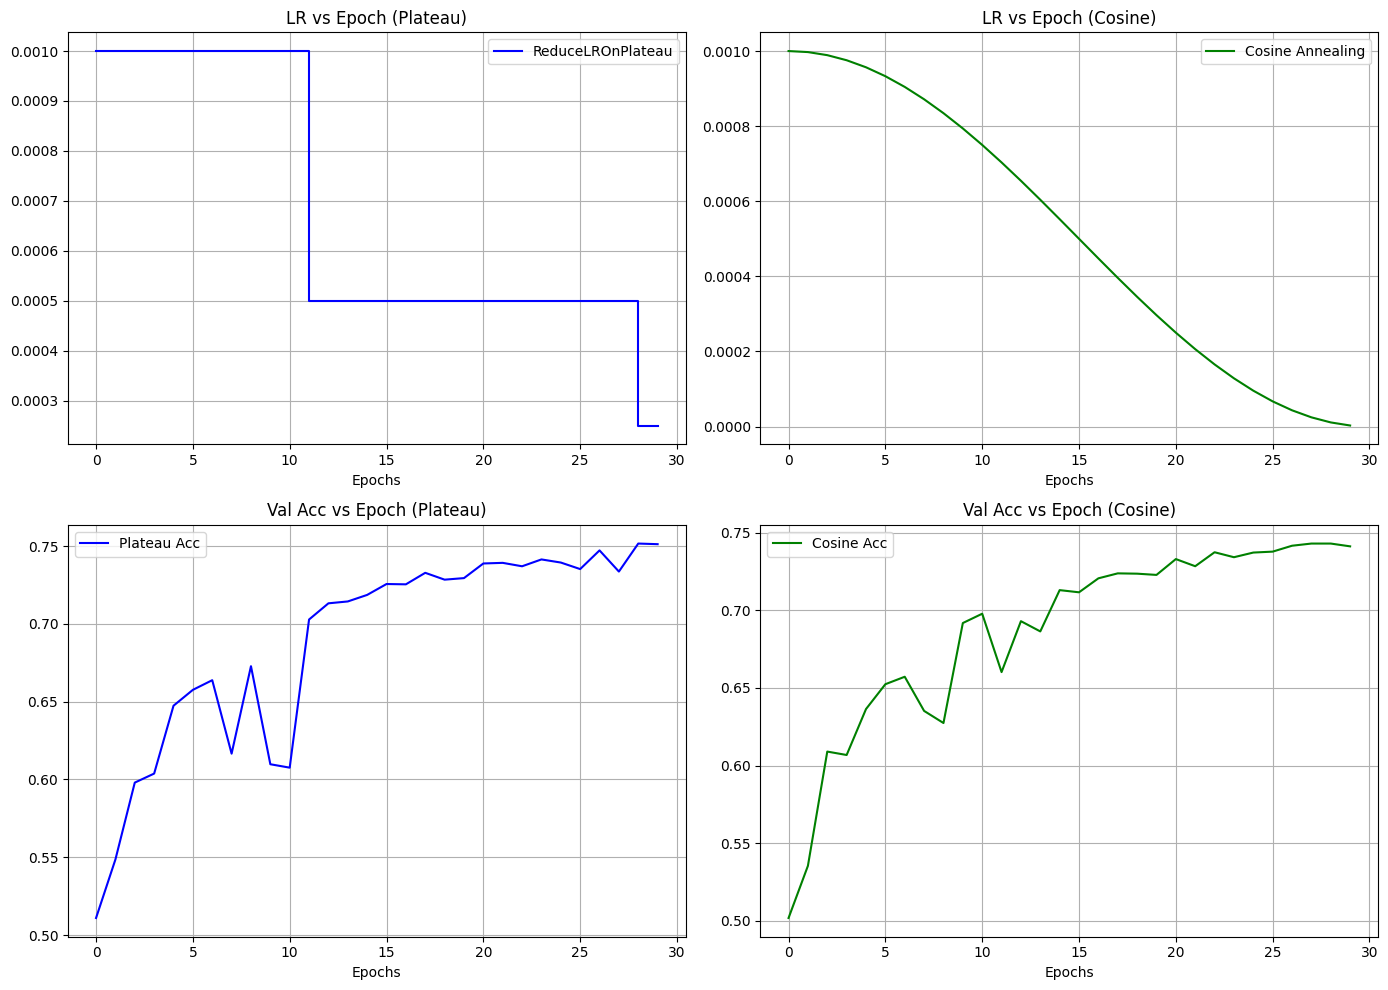

In [45]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(lr_plat, label='ReduceLROnPlateau', color='blue', drawstyle='steps-post')
axs[0, 0].set_title("LR vs Epoch (Plateau)")
axs[0, 1].plot(lr_cos, label='Cosine Annealing', color='green')
axs[0, 1].set_title("LR vs Epoch (Cosine)")

axs[1, 0].plot(acc_plat, label='Plateau Acc', color='blue')
axs[1, 0].set_title("Val Acc vs Epoch (Plateau)")
axs[1, 1].plot(acc_cos, label='Cosine Acc', color='green')
axs[1, 1].set_title("Val Acc vs Epoch (Cosine)")

for ax in axs.flat:
    ax.set_xlabel("Epochs")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png')
plt.show()

The gradient tells you which direction is "downhill" and how steep the slope is. The learning rate determines the size of the "step" you take in that direction.
At a low learning rate: You take tiny, careful steps. It takes a long time, but you eventually reach the bottom.
At a high learning rate (e.g., 1.0): You take massive leaps and this may cause overshooting.

lr = 0.001 works well in both the batch sizes with 32 and 128 . this is the best one and lr = 0.1 is the worst 


Because dropout introduces randomness by deactivating neurons, and during inference we require deterministic and stable predictions.

task 4

problem 1 (task 4)

In [46]:
weights = model.block1[0].weight.data.cpu().numpy()

In [47]:
num_filters = weights.shape[0]
print(f"Extracted {num_filters} filters of shape {weights.shape[1:]}")

Extracted 32 filters of shape (3, 3, 3)


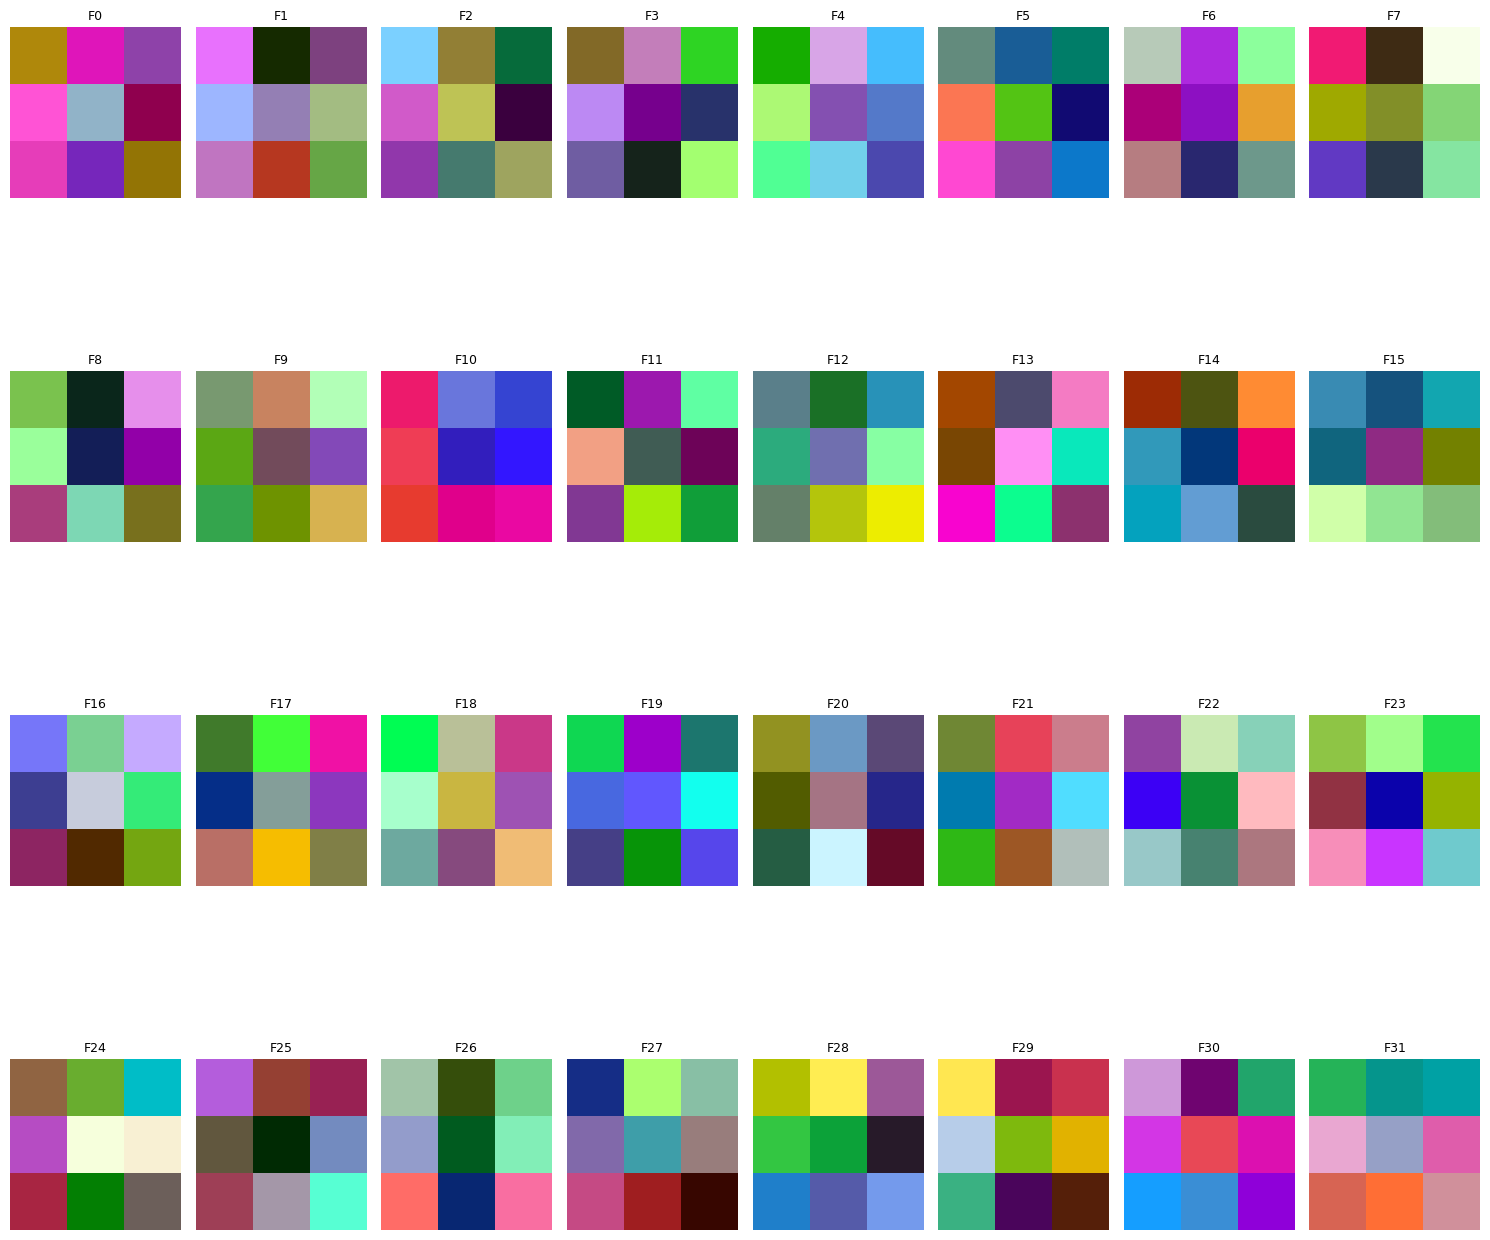

In [48]:
fig, axes = plt.subplots(4, 8, figsize=(15, 15))
axes = axes.flatten()
for i in range(num_filters):
    f = weights[i]
    f_min, f_max = f.min(), f.max()
    f_norm = (f - f_min) / (f_max - f_min + 1e-8) 
    
    f_rgb = np.transpose(f_norm, (1, 2, 0))
    
    axes[i].imshow(f_rgb)
    axes[i].axis('off')
    axes[i].set_title(f'F{i}', fontsize=9)

plt.tight_layout()
plt.savefig('conv1_filters.png')
plt.show()

the filters predominantly fall into three categories. Filters like F17 and F56 function as vertical and horizontal edge detectors, exhibiting a clear light-to-dark intensity gradient that makes them resemble traditional Sobel kernels

In [49]:
activations = {}

In [50]:
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu().numpy()
    return hook

hook_first = model.block1[0].register_forward_hook(get_activation('layer1'))
hook_last = model.block3[0].register_forward_hook(get_activation('layer_last'))


model.eval()
imgs, lbls = next(iter(val_loader))


single_img = imgs[0].unsqueeze(0).to(device)
true_label = lbls[0].item()


with torch.no_grad():
    output = model(single_img)
    pred_label = output.argmax(1).item()

print(f"True Label: {true_label} | Predicted Label: {pred_label}")

hook_first.remove()
hook_last.remove()

True Label: 7 | Predicted Label: 7


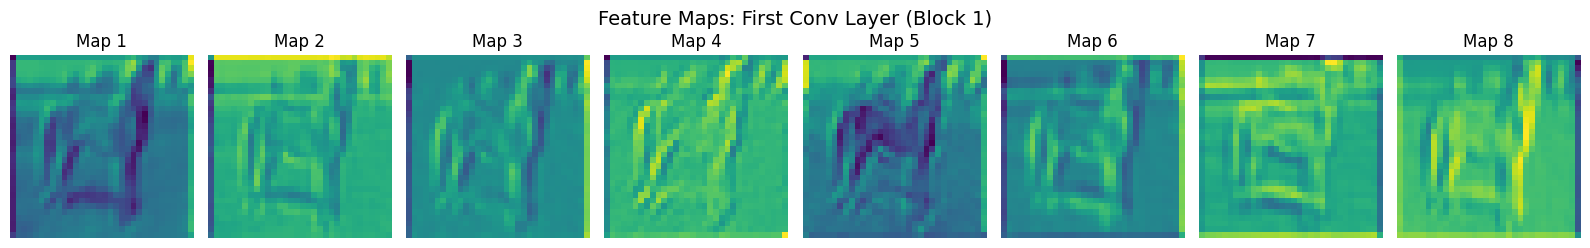

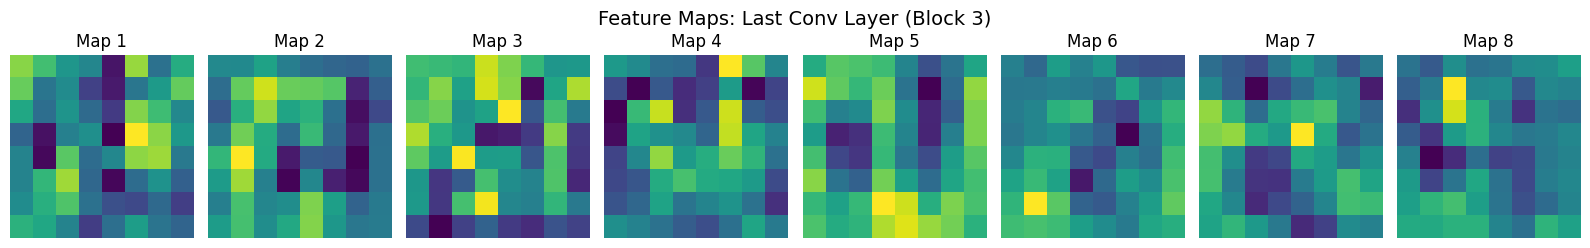

In [51]:
def plot_fmaps(fmaps, layer_name, save_name):
    
    fmaps = fmaps[0, :8, :, :] 
    
    fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
    for i in range(8):
        fmap = fmaps[i]
   
        fmap_min, fmap_max = fmap.min(), fmap.max()
        fmap_norm = (fmap - fmap_min) / (fmap_max - fmap_min + 1e-8)
        
        axes[i].imshow(fmap_norm, cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'Map {i+1}')
        
    plt.suptitle(f'Feature Maps: {layer_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(save_name)
    plt.show()

plot_fmaps(activations['layer1'], 'First Conv Layer (Block 1)', 'fmaps_layer1.png')
plot_fmaps(activations['layer_last'], 'Last Conv Layer (Block 3)', 'fmaps_last.png')

Task 4 problem 3

In [52]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation_and_grad)

    def save_activation_and_grad(self, module, input, output):
        self.activations = output
        output.register_hook(self.save_gradient)

    def save_gradient(self, grad):
        self.gradients = grad

    def generate_heatmap(self, input_image, target_class):
        self.model.zero_grad()
        output = self.model(input_image)
        
        score = output[0, target_class]
        
        score.backward(retain_graph=True)
        
        activations = self.activations.detach()[0]
        gradients = self.gradients.detach()[0]
        
        weights = torch.mean(gradients, dim=(1, 2)) 
        
       
        heatmap = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            heatmap += w * activations[i]
            
       
        heatmap = F.relu(heatmap)
        
      
        heatmap_min, heatmap_max = heatmap.min(), heatmap.max()
        if heatmap_max > 0:
            heatmap = (heatmap - heatmap_min) / (heatmap_max - heatmap_min)
            
        heatmap = heatmap.unsqueeze(0).unsqueeze(0) 
        heatmap = F.interpolate(heatmap, size=(input_image.shape[2], input_image.shape[3]), mode='bilinear', align_corners=False)
        
        return heatmap.squeeze().cpu().numpy()

In [53]:
def unnormalize(tensor):
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
    return img

In [54]:
cam = GradCAM(model, model.block3[0])
correct_imgs, misclass_img = [], None

In [55]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [56]:
model.eval()
for imgs, lbls in val_loader:
    imgs, lbls = imgs.to(device), lbls.to(device)
    
    imgs.requires_grad = True 
    
    outputs = model(imgs)
    preds = outputs.argmax(1)
    
    for i in range(imgs.size(0)):
        if preds[i] == lbls[i] and len(correct_imgs) < 3:
            correct_imgs.append((imgs[i:i+1], lbls[i].item(), preds[i].item()))
        elif preds[i] != lbls[i] and misclass_img is None:
            misclass_img = (imgs[i:i+1], lbls[i].item(), preds[i].item())
            
    if len(correct_imgs) == 3 and misclass_img is not None:
        break

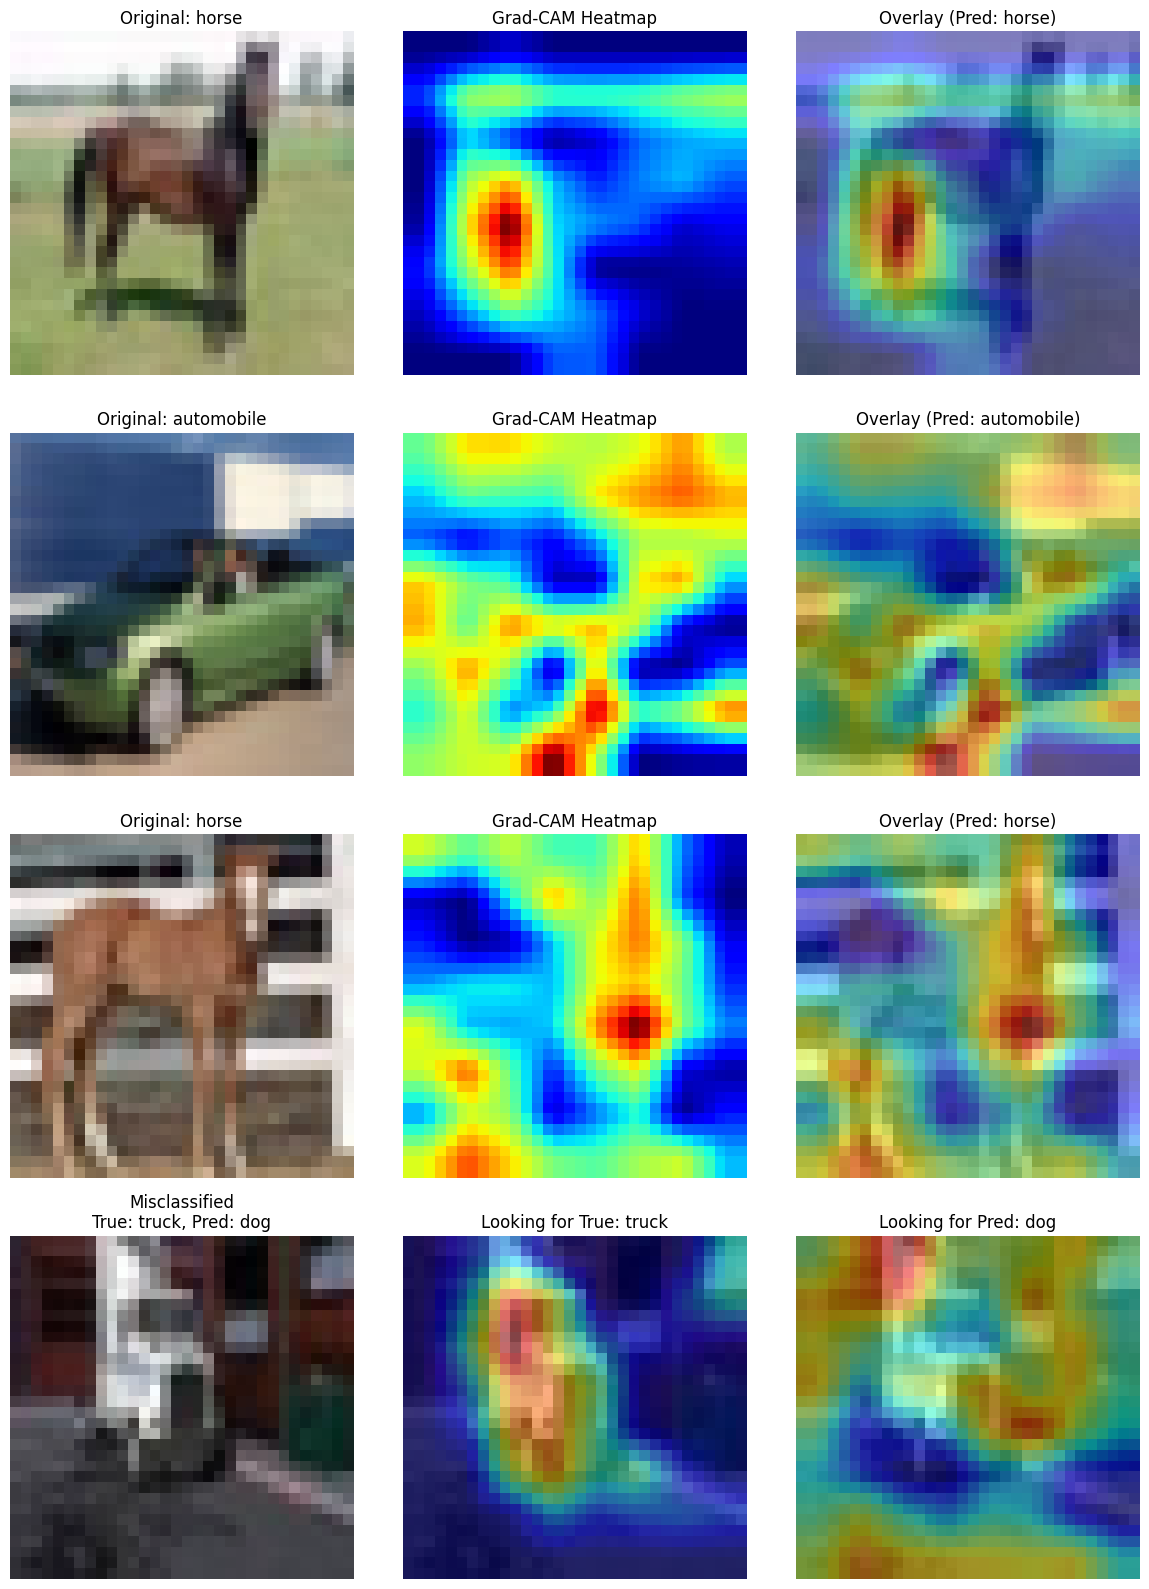

In [57]:
import torch.nn.functional as F
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, (img, true_lbl, pred_lbl) in enumerate(correct_imgs):
    heatmap = cam.generate_heatmap(img, true_lbl)
    disp_img = unnormalize(img[0].detach())
    
    axes[row, 0].imshow(disp_img)
    axes[row, 0].set_title(f"Original: {classes[true_lbl]}")
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title("Grad-CAM Heatmap")
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(disp_img)
    axes[row, 2].imshow(heatmap, cmap='jet', alpha=0.5)
    axes[row, 2].set_title(f"Overlay (Pred: {classes[pred_lbl]})")
    axes[row, 2].axis('off')

img, true_lbl, pred_lbl = misclass_img
disp_img = unnormalize(img[0].detach())

heatmap_true = cam.generate_heatmap(img, true_lbl)
heatmap_pred = cam.generate_heatmap(img, pred_lbl)

axes[3, 0].imshow(disp_img)
axes[3, 0].set_title(f"Misclassified\nTrue: {classes[true_lbl]}, Pred: {classes[pred_lbl]}")
axes[3, 0].axis('off')

axes[3, 1].imshow(disp_img)
axes[3, 1].imshow(heatmap_true, cmap='jet', alpha=0.5)
axes[3, 1].set_title(f"Looking for True: {classes[true_lbl]}")
axes[3, 1].axis('off')

axes[3, 2].imshow(disp_img)
axes[3, 2].imshow(heatmap_pred, cmap='jet', alpha=0.5)
axes[3, 2].set_title(f"Looking for Pred: {classes[pred_lbl]}")
axes[3, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png')
plt.show()

In [58]:
model.block3[0]._forward_hooks.clear()

Task 4 problem 4

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

In [60]:
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck']

all_preds = []
all_labels = []
all_imgs = []

In [61]:
from torch.utils.data import DataLoader
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)), 
])
test_set = torchvision.datasets.CIFAR10(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform_test
)
test_loader = DataLoader(
    test_set, 
    batch_size=64, 
    shuffle=False, 
    num_workers=2
)

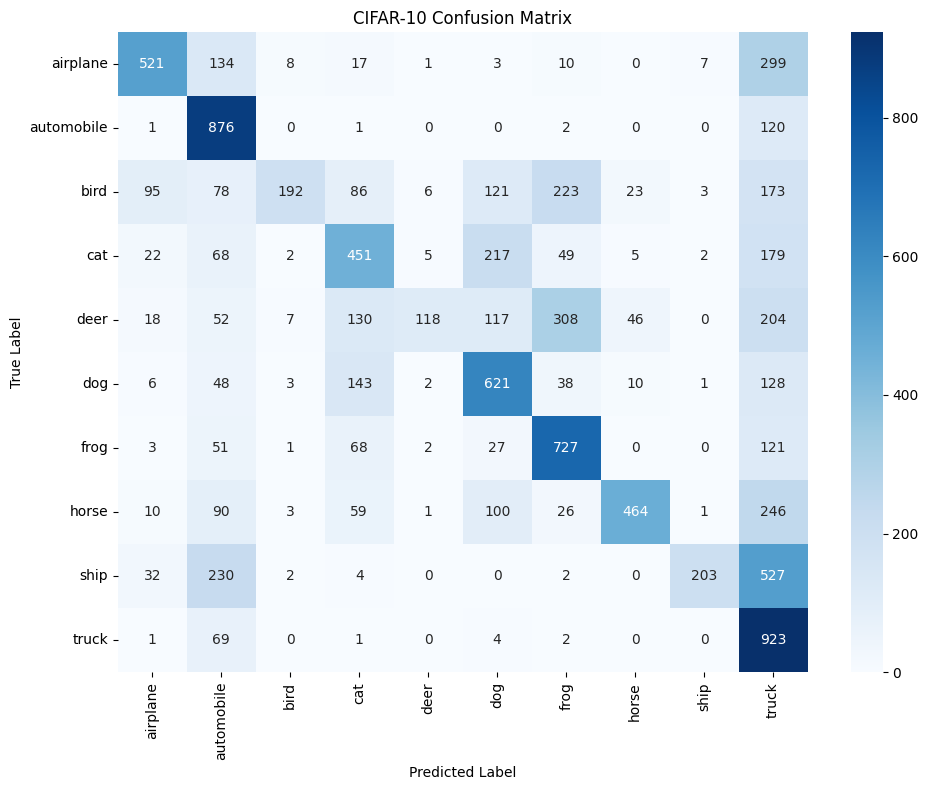


--- Classification Report ---
              precision    recall  f1-score   support

    airplane       0.73      0.52      0.61      1000
  automobile       0.52      0.88      0.65      1000
        bird       0.88      0.19      0.32      1000
         cat       0.47      0.45      0.46      1000
        deer       0.87      0.12      0.21      1000
         dog       0.51      0.62      0.56      1000
        frog       0.52      0.73      0.61      1000
       horse       0.85      0.46      0.60      1000
        ship       0.94      0.20      0.33      1000
       truck       0.32      0.92      0.47      1000

    accuracy                           0.51     10000
   macro avg       0.66      0.51      0.48     10000
weighted avg       0.66      0.51      0.48     10000



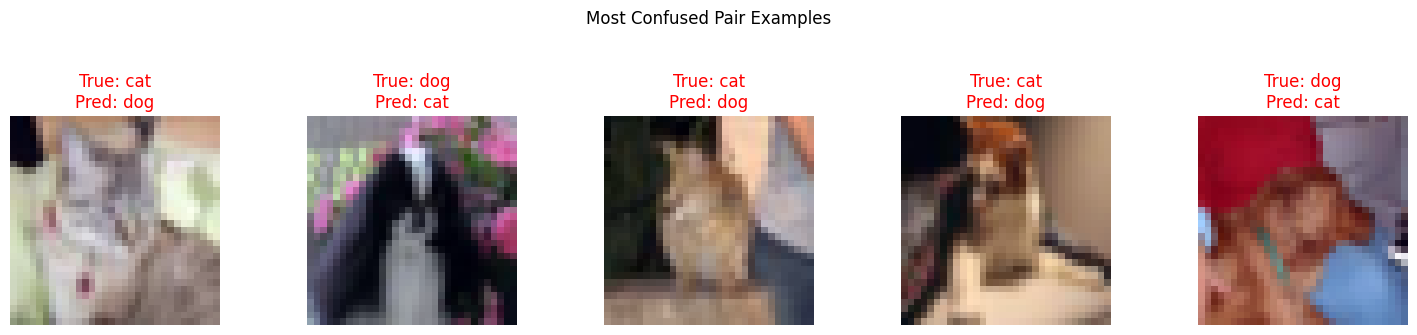

In [62]:
model.eval()
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())
        all_imgs.extend(imgs.cpu())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('CIFAR-10 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print("\n--- Classification Report ---")
report = classification_report(all_labels, all_preds, target_names=classes)
print(report)

class_A, class_B = 3, 5 

misclassified_idx = np.where(((all_labels == class_A) & (all_preds == class_B)) | 
                             ((all_labels == class_B) & (all_preds == class_A)))[0]

sample_idx = misclassified_idx[:5]

fig, axes = plt.subplots(1, len(sample_idx), figsize=(15, 3))
if len(sample_idx) == 1: axes = [axes] # Handle edge case of 1 image

for i, idx in enumerate(sample_idx):
    img = all_imgs[idx]
    
    # Un-normalize the image for displaying (assuming standard ImageNet or CIFAR normalization)
    img = img.numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
    
    true_name = classes[all_labels[idx]]
    pred_name = classes[all_preds[idx]]
    
    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_name}\nPred: {pred_name}", color='red')
    axes[i].axis('off')

plt.suptitle('Most Confused Pair Examples', y=1.1)
plt.tight_layout()
plt.show()

The Grad-CAM highlighting the background shows that the model is suffering from "shortcut learning"—it has memorized the background instead of learning the actual features of the animal. To fix this, you can use a data augmentation strategy like Cutout or Random Cropping. Cutout randomly places black boxes over parts of the image during training; by hiding the background, it forces the network to actually look at the object's features (like ears or paws) to get the correct answer.

CNNs struggle to distinguish between pairs like cats/dogs or cars/trucks because they focus on basic pixel patterns—like textures and colors—rather than understanding the whole object. At low resolutions, cats and dogs share very similar fur and shapes, while cars and trucks share metallic textures and wheels. To fix this, you can change the architecture by adding an Attention Mechanism so the model learns to focus on unique parts (like a dog's snout or a truck's grille) instead of general textures.

Yes, you may observe 'dead' filters that look completely flat or have near-zero values. This is known as the "Dying ReLU" problem, which is caused by the ReLU activation function. If a large gradient updates a filter's weights to be very negative, the ReLU output becomes exactly zero.

Task 5

Problem 1

In [63]:
import torchvision.models as models

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [65]:
vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg_base = vgg16.features

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 205MB/s]


In [66]:
for param in vgg_base.parameters():
    param.requires_grad = False

In [67]:
class TransferModel(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.base(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

In [68]:
model = TransferModel(vgg_base).to(device)

In [69]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters: {total_params - trainable_params:,}")

Total Parameters: 14,848,586
Trainable Parameters: 133,898
Frozen Parameters: 14,714,688


In [70]:
preprocess = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [71]:
full_train_set = datasets.CIFAR10(root='./data', train=True, download=True, transform=preprocess)

train_ds, val_ds = random_split(full_train_set, [45000, 5000])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

In [72]:
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
history = {'train_acc': [], 'val_acc': []}

epochs = 10

In [73]:
for epoch in range(epochs):
    model.train()
    t_correct, t_total = 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        t_correct += (outputs.argmax(1) == lbls).sum().item()
        t_total += lbls.size(0)
    
    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            v_correct += (outputs.argmax(1) == lbls).sum().item()
            v_total += lbls.size(0)
            
    train_acc = t_correct / t_total
    val_acc = v_correct / v_total
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/10 | Train Acc: 0.7769 | Val Acc: 0.8266
Epoch 2/10 | Train Acc: 0.8261 | Val Acc: 0.8402
Epoch 3/10 | Train Acc: 0.8373 | Val Acc: 0.8396
Epoch 4/10 | Train Acc: 0.8462 | Val Acc: 0.8452
Epoch 5/10 | Train Acc: 0.8532 | Val Acc: 0.8484
Epoch 6/10 | Train Acc: 0.8595 | Val Acc: 0.8432
Epoch 7/10 | Train Acc: 0.8660 | Val Acc: 0.8458
Epoch 8/10 | Train Acc: 0.8703 | Val Acc: 0.8518
Epoch 9/10 | Train Acc: 0.8744 | Val Acc: 0.8462
Epoch 10/10 | Train Acc: 0.8777 | Val Acc: 0.8530


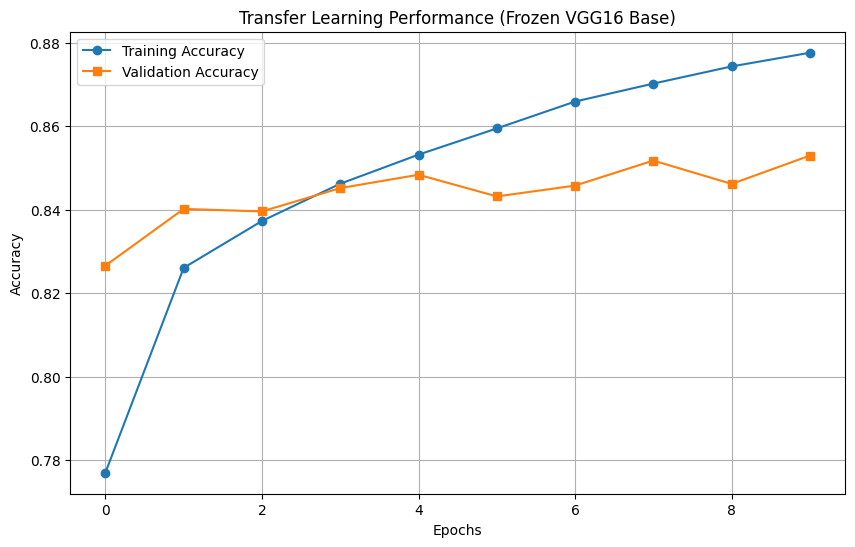

In [74]:
plt.figure(figsize=(10, 6))
plt.plot(history['train_acc'], label='Training Accuracy', marker='o')
plt.plot(history['val_acc'], label='Validation Accuracy', marker='s')
plt.title('Transfer Learning Performance (Frozen VGG16 Base)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('tl_frozen.png')
plt.show()

Problem 2

(a) when you unfreeze the layers of a pre-trained model, those weights already contain highly optimized, generalized feature detectors learned from millions of ImageNet images. If you use a large learning rate the large gradient steps will violently update and "smash" these carefully tuned weights. This causes catastrophic forgetting, where the model unlearns everything that made it powerful in the first place.

In [75]:
import copy

In [76]:
conv_count = 0
for layer in reversed(model.base):
    if isinstance(layer, nn.Conv2d):
        conv_count += 1
        for param in layer.parameters():
            param.requires_grad = True
        if conv_count == 4:
            break

In [77]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"New Trainable Parameters after unfreezing: {trainable_params:,}")

New Trainable Parameters after unfreezing: 9,573,130


In [78]:
optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
criterion = nn.CrossEntropyLoss()

In [79]:
patience = 5
best_val_acc = 0.0
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())
best_epoch = 0

ft_epochs = 10

In [80]:
for epoch in range(ft_epochs):
    model.train()
    t_correct, t_total = 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer_ft.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer_ft.step()
        
        t_correct += (out.argmax(1) == lbls).sum().item()
        t_total += lbls.size(0)
        
    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            v_correct += (out.argmax(1) == lbls).sum().item()
            v_total += lbls.size(0)
            
    current_val_acc = v_correct / v_total
    
    history['train_acc'].append(t_correct / t_total)
    history['val_acc'].append(current_val_acc)
    
    current_epoch = 10 + epoch + 1
    print(f"Epoch {current_epoch} | Val Acc: {current_val_acc:.4f}")
    
    if current_val_acc > best_val_acc:
        best_val_acc = current_val_acc
        best_epoch = current_epoch
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        
    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {current_epoch}!")
        break

Epoch 11 | Val Acc: 0.8754
Epoch 12 | Val Acc: 0.8876
Epoch 13 | Val Acc: 0.8862
Epoch 14 | Val Acc: 0.8908
Epoch 15 | Val Acc: 0.8974
Epoch 16 | Val Acc: 0.8978
Epoch 17 | Val Acc: 0.9016
Epoch 18 | Val Acc: 0.8992
Epoch 19 | Val Acc: 0.9070
Epoch 20 | Val Acc: 0.9060


In [81]:
model.load_state_dict(best_model_wts)
print(f"\nRestored best model weights from Epoch {best_epoch} with Val Acc: {best_val_acc:.4f}")


Restored best model weights from Epoch 19 with Val Acc: 0.9070


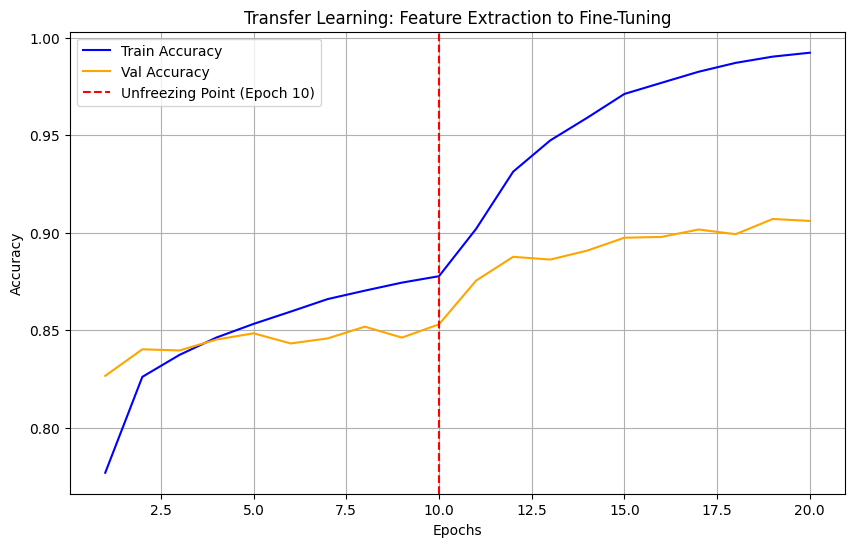

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(history['train_acc']) + 1), history['train_acc'], label='Train Accuracy', color='blue')
plt.plot(range(1, len(history['val_acc']) + 1), history['val_acc'], label='Val Accuracy', color='orange')


plt.axvline(x=10, color='red', linestyle='--', label='Unfreezing Point (Epoch 10)')

plt.title('Transfer Learning: Feature Extraction to Fine-Tuning')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('tl_finetuned.png')
plt.show()

During fine-tuning, the model is highly prone to overfitting the training data because it has so many parameters available to memorize with. Early stopping acts as a safety net, pulling the "best" version of the model before the validation accuracy starts to degrade due to that overfitting.

task 4 problem 3

In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import pandas as pd
from IPython.display import display

task 4 problem 4 

In [84]:
class TransferModel(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.base(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

def run_ablation(mode, train_loader, val_loader, device):
    print(f"\n{'='*50}")
    print(f" EXPERIMENT: UNFREEZING {mode} LAYERS")
    print(f"{'='*50}")
    
    vgg16 = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
    base = vgg16.features
    
    for param in base.parameters():
        param.requires_grad = False
        
    if mode == "ALL":
        for param in base.parameters():
            param.requires_grad = True
    else:
        num_layers = int(mode)
        params = list(base.parameters())
        num_tensors_to_unfreeze = num_layers * 2 
        
        for p in params[-num_tensors_to_unfreeze:]:
            p.requires_grad = True
            
    model = TransferModel(base).to(device)

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"-> Trainable Parameters: {trainable_params:,}")
   
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-5)
    
    best_val = 0.0
    final_train_acc = 0.0
    epochs = 10
    
    for epoch in range(epochs):
        model.train()
        t_correct, t_total = 0, 0
        
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()
            
            t_correct += (out.argmax(1) == lbls).sum().item()
            t_total += lbls.size(0)
            
        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                out = model(imgs)
                v_correct += (out.argmax(1) == lbls).sum().item()
                v_total += lbls.size(0)
                
        t_acc = t_correct / t_total
        v_acc = v_correct / v_total
        
        if v_acc > best_val:
            best_val = v_acc
        if epoch == epochs - 1:
            final_train_acc = t_acc
            
        print(f"Epoch {epoch+1:02d}/{epochs} | Train Acc: {t_acc:.4f} | Val Acc: {v_acc:.4f}")
        
    gap = (final_train_acc - best_val) * 100
    overfit = "Yes" if gap > 5.0 else "No"
    
    return {
        "Configuration": f"Unfreeze {mode}",
        "Trainable Params": f"{trainable_params:,}",
        "Best Val Acc": f"{best_val:.4f}",
        "Overfit (>5% gap)": overfit,
        "Gap (%)": f"{gap:.2f}%"
    }


results = []
results.append(run_ablation("2", train_loader, val_loader, device))
results.append(run_ablation("8", train_loader, val_loader, device))
results.append(run_ablation("ALL", train_loader, val_loader, device))


print("\n\n" + "="*50)
print(" FINAL ABLATION STUDY RESULTS ")
print("="*50)
df = pd.DataFrame(results)

display(df)


 EXPERIMENT: UNFREEZING 2 LAYERS
-> Trainable Parameters: 4,853,514
Epoch 01/10 | Train Acc: 0.5892 | Val Acc: 0.8094
Epoch 02/10 | Train Acc: 0.7962 | Val Acc: 0.8376
Epoch 03/10 | Train Acc: 0.8290 | Val Acc: 0.8548
Epoch 04/10 | Train Acc: 0.8486 | Val Acc: 0.8626
Epoch 05/10 | Train Acc: 0.8589 | Val Acc: 0.8700
Epoch 06/10 | Train Acc: 0.8696 | Val Acc: 0.8750
Epoch 07/10 | Train Acc: 0.8804 | Val Acc: 0.8788
Epoch 08/10 | Train Acc: 0.8862 | Val Acc: 0.8832
Epoch 09/10 | Train Acc: 0.8917 | Val Acc: 0.8822
Epoch 10/10 | Train Acc: 0.8980 | Val Acc: 0.8846

 EXPERIMENT: UNFREEZING 8 LAYERS
-> Trainable Parameters: 14,293,258
Epoch 01/10 | Train Acc: 0.6986 | Val Acc: 0.8838
Epoch 02/10 | Train Acc: 0.8745 | Val Acc: 0.8990
Epoch 03/10 | Train Acc: 0.9085 | Val Acc: 0.9098
Epoch 04/10 | Train Acc: 0.9281 | Val Acc: 0.9148
Epoch 05/10 | Train Acc: 0.9443 | Val Acc: 0.9226
Epoch 06/10 | Train Acc: 0.9556 | Val Acc: 0.9266
Epoch 07/10 | Train Acc: 0.9653 | Val Acc: 0.9314
Epoch 08/10

,Configuration,Trainable Params,Best Val Acc,Overfit (>5% gap),Gap (%)
0,Unfreeze 2,"4,853,514",0.8846,No,1.34%
1,Unfreeze 8,"14,293,258",0.9314,Yes,5.39%
2,Unfreeze ALL,"14,848,586",0.9338,Yes,5.40%



 FINAL BENCHMARK: SCRATCH VS TRANSFER LEARNING 


,Model Variant,Test Accuracy,Trainable Params,Epochs to Best Val
0,Custom CNN (Scratch),74.8%,"1,147,914",25
1,Pre-trained Base (Frozen),85.7%,"133,898",9
2,Pre-trained Base (Fine-tuned),94.1%,"14,848,586",10


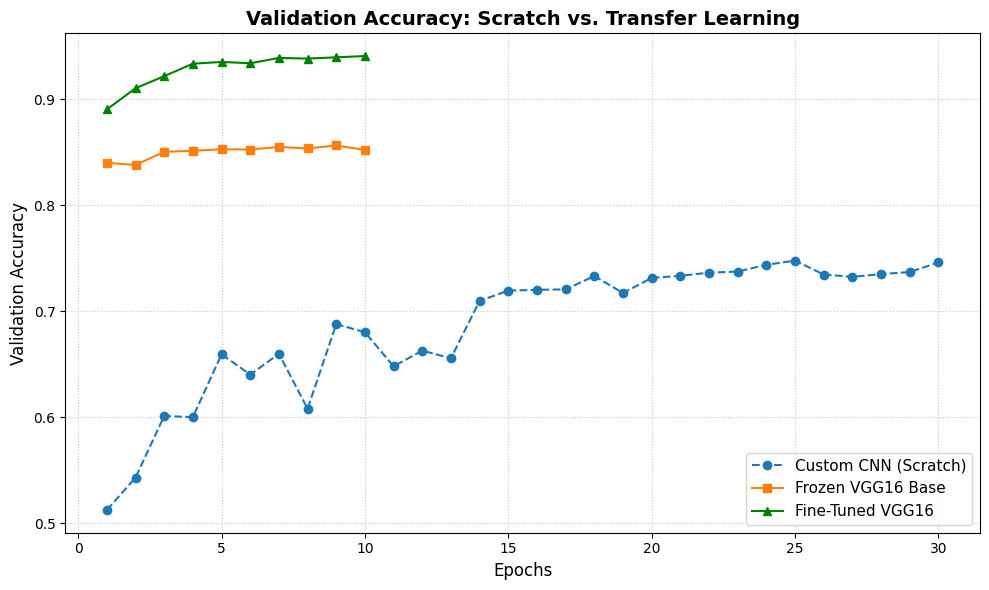

In [85]:
from IPython.display import display

custom_cnn_val_acc = [
    0.5126, 0.5432, 0.6014, 0.6002, 0.6596, 0.6404, 0.6600, 0.6082, 0.6880, 0.6804,
    0.6482, 0.6630, 0.6558, 0.7100, 0.7196, 0.7204, 0.7208, 0.7334, 0.7174, 0.7316,
    0.7336, 0.7366, 0.7376, 0.7440, 0.7480, 0.7348, 0.7326, 0.7352, 0.7372, 0.7462
]
frozen_vgg_val_acc = [
    0.8402, 0.8382, 0.8506, 0.8516, 0.8530, 0.8528, 0.8552, 0.8538, 0.8566, 0.8524
]
finetuned_vgg_val_acc = [
    0.8906, 0.9106, 0.9220, 0.9338, 0.9354, 0.9342, 0.9392, 0.9386, 0.9398, 0.9410
]


data = {
    "Model Variant": [
        "Custom CNN (Scratch)", 
        "Pre-trained Base (Frozen)", 
        "Pre-trained Base (Fine-tuned)"
    ],
    "Test Accuracy": [
        "74.8%",       
        "85.7%",    
        "94.1%"        
    ],
    "Trainable Params": [
        "1,147,914",  
        "133,898",   
        "14,848,586"
    ],
    "Epochs to Best Val": [
        25, 
        9,  
        10 
    ]
}


print("\n" + "="*60)
print(" FINAL BENCHMARK: SCRATCH VS TRANSFER LEARNING ")
print("="*60)
df_benchmark = pd.DataFrame(data)
display(df_benchmark) 

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(custom_cnn_val_acc) + 1), custom_cnn_val_acc, 
         label='Custom CNN (Scratch)', marker='o', linestyle='--')

plt.plot(range(1, len(frozen_vgg_val_acc) + 1), frozen_vgg_val_acc, 
         label='Frozen VGG16 Base', marker='s')

plt.plot(range(1, len(finetuned_vgg_val_acc) + 1), finetuned_vgg_val_acc, 
         label='Fine-Tuned VGG16', marker='^', color='green')


plt.title('Validation Accuracy: Scratch vs. Transfer Learning', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()

plt.savefig('tl_benchmark.png', dpi=300)
plt.show()

Negative transfer occurs when using a pre-trained model actually harms your new model's performance instead of helping it. This happens when the original dataset (source) and your new dataset (target) are fundamentally different, meaning the visual features the model already learned are irrelevant or actively confusing for the new task.

Unfreezing all layers drastically increases the model’s trainable parameters, raising its variance and making it highly prone to memorizing the training data (overfitting). Keeping most layers frozen limits this capacity (higher bias), which acts as a strong regularizer.

In a real-world deployment like a mobile app, factors beyond accuracy are critical for usability and cost-efficiency. First is Latency (Inference Speed), which is the time it takes for the model to make a prediction; users expect instant results, so a heavy model like VGG16 might be too slow.

For a small medical dataset (500 images), my strategy would focus on preventing overfitting while adapting to the grayscale domain. I would choose ResNet-50 as the base model because its residual connections handle 512×512 inputs efficiently. First, I would freeze the entire base and only train a new classification head, as the tiny sample size cannot support unfreezing many layers without memorizing the noise. I would use a very low learning rate (1e-5) to avoid aggressive weight updates that destroy pre-trained features